# Ganesh Thammana

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load the dataset
df = pd.read_csv('ChurnZero_dataset_v1.csv')

# Basic information
print("=" * 80)
print("DATASET OVERVIEW")
print("=" * 80)
print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nTarget Variable Distribution:")
print(df['churn'].value_counts())
print(f"\nChurn Rate: {df['churn'].mean()*100:.2f}%")
print("\n" + "=" * 80)
print("COLUMN DATA TYPES")
print("=" * 80)
print(df.dtypes)

DATASET OVERVIEW
Dataset Shape: 8101 rows × 98 columns

Target Variable Distribution:
churn
0    6799
1    1302
Name: count, dtype: int64

Churn Rate: 16.07%

COLUMN DATA TYPES
customer_id                    int64
churn                          int64
age                            int64
gender                        object
marital_status                object
                              ...   
credit_utilization_6m_avg    float64
avg_quarterly_balance        float64
total_digital_logins           int64
debt_to_income_ratio         float64
digital_engagement_index     float64
Length: 98, dtype: object


In [2]:
# Missing values analysis
print("=" * 80)
print("MISSING VALUES ANALYSIS")
print("=" * 80)
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
print(missing_data.to_string(index=False))
print(f"\nTotal columns with missing values: {len(missing_data)}")

MISSING VALUES ANALYSIS
          Column  Missing_Count  Missing_Percentage
app_rating_given           4541               56.05

Total columns with missing values: 1


In [3]:
# Summary statistics for numerical features
print("=" * 80)
print("SUMMARY STATISTICS - KEY NUMERICAL FEATURES")
print("=" * 80)

key_features = ['age', 'annual_income', 'tenure_months', 'number_of_products',
                'customer_lifetime_value', 'avg_monthly_balance', 'current_balance',
                'monthly_transaction_count', 'total_trans_count', 'satisfaction_score',
                'nps_score', 'digital_engagement_index']

summary_stats = df[key_features].describe().T
summary_stats['missing'] = df[key_features].isnull().sum()
print(summary_stats.round(2))

SUMMARY STATISTICS - KEY NUMERICAL FEATURES
                            count      mean       std       min       25%  \
age                        8101.0     46.39      7.99     26.00     41.00   
annual_income              8101.0  60052.87  35422.47  18000.00  31813.00   
tenure_months              8101.0     36.01      7.93     13.00     32.00   
number_of_products         8101.0      3.81      1.55      1.00      3.00   
customer_lifetime_value    8101.0  14102.42  10603.99    733.48   6563.31   
avg_monthly_balance        8101.0  15212.15  13006.19   1000.00   6905.00   
current_balance            8101.0  15999.15  14196.95    728.00   7003.00   
monthly_transaction_count  8101.0      4.93      1.99      1.00      3.00   
total_trans_count          8101.0     64.70     23.61     10.00     45.00   
satisfaction_score         8101.0      3.63      0.95      1.00      3.00   
nps_score                  8101.0     33.60     35.55    -95.00      9.00   
digital_engagement_index   8101.

/tmp/ipykernel_3487/3857189239.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels(['No Churn', 'Churn'])
/tmp/ipykernel_3487/3857189239.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 2].set_xticklabels(['No Churn', 'Churn'])
/tmp/ipykernel_3487/3857189239.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2, 0].set_xticklabels(['No Churn', 'Churn'])


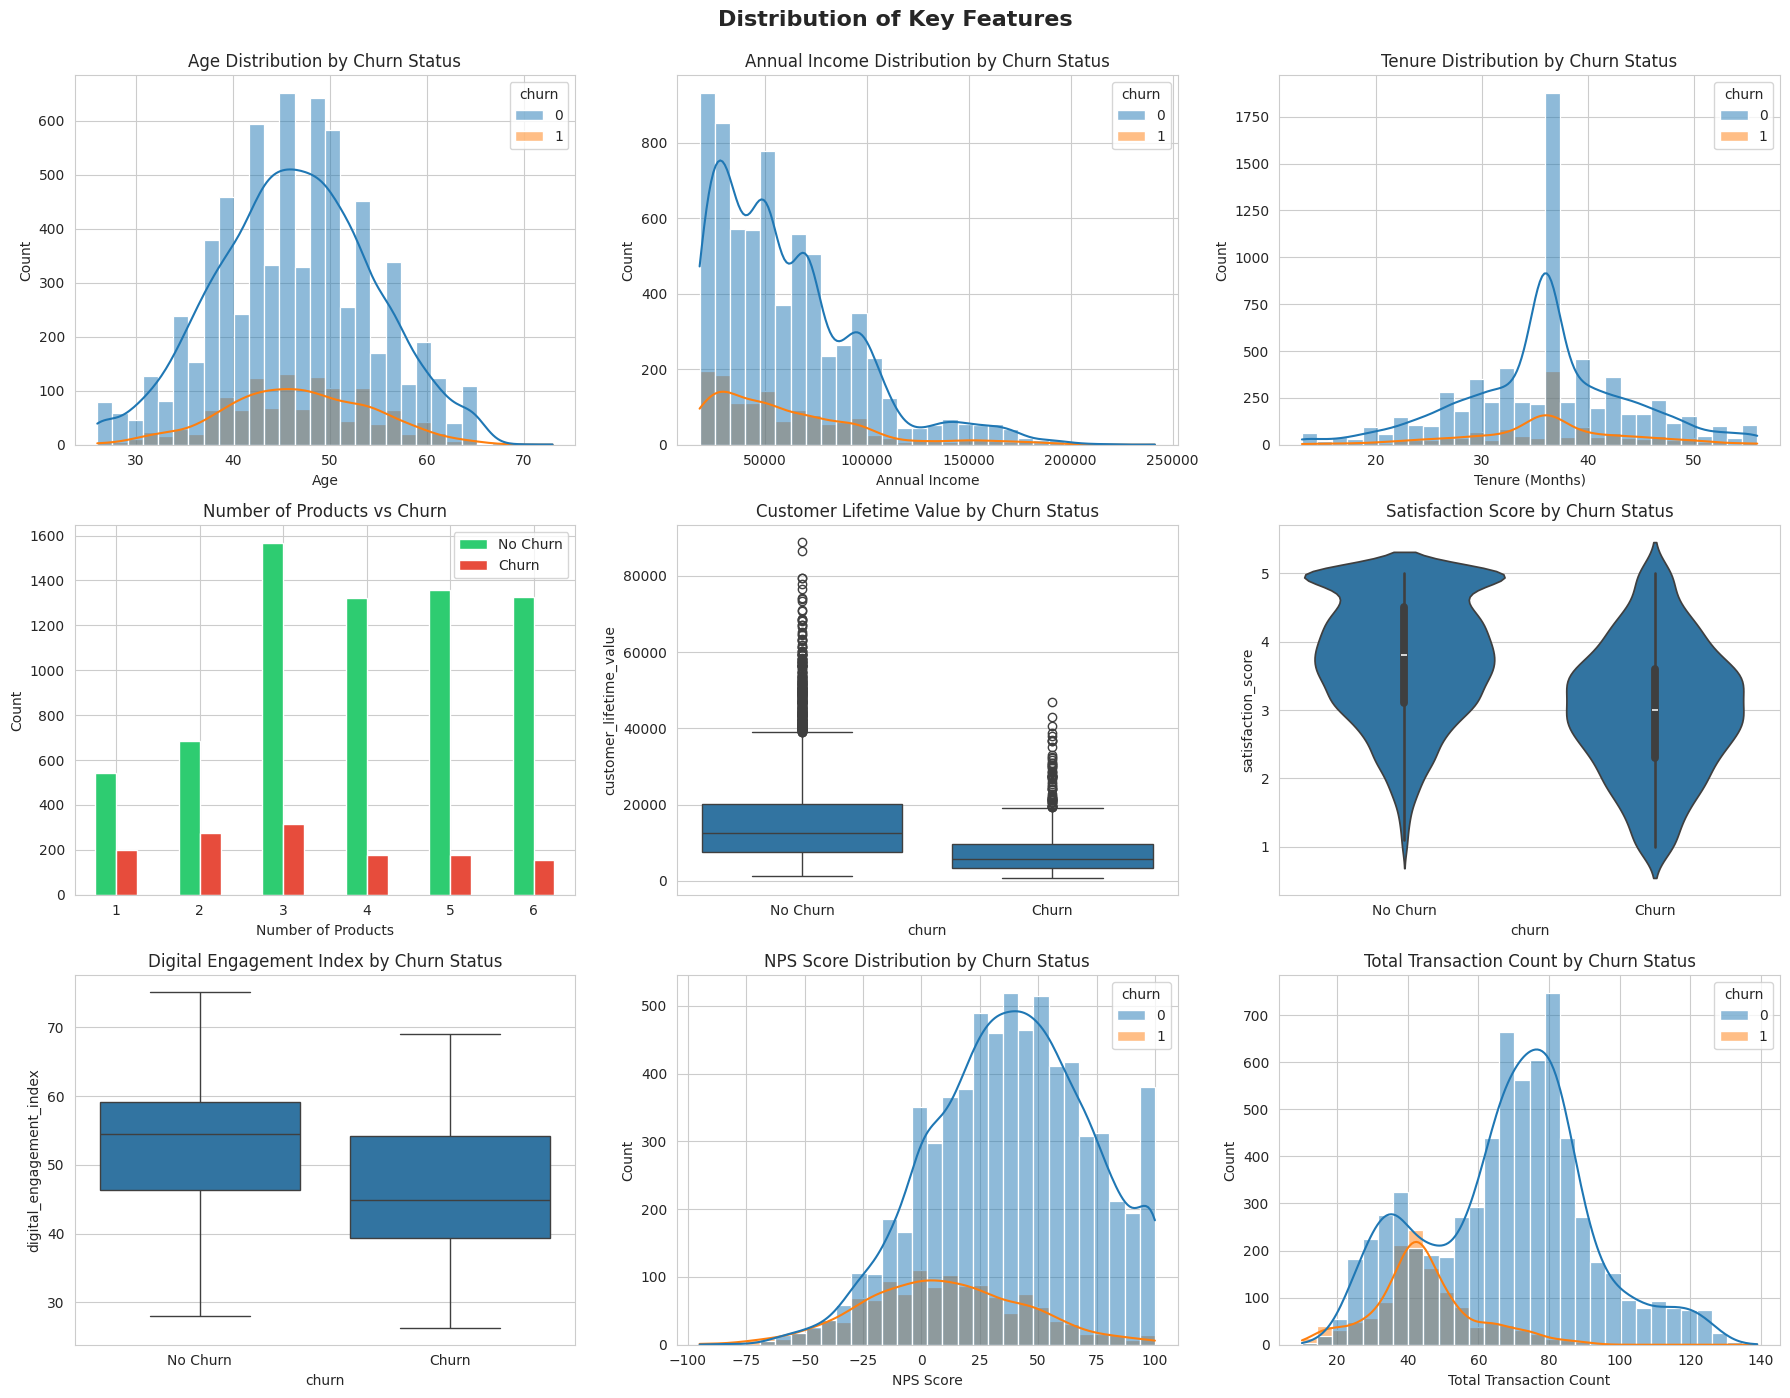

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

# Create subplots
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Distribution of Key Features', fontsize=16, fontweight='bold', y=0.995)

# 1. Age distribution by churn
sns.histplot(data=df, x='age', hue='churn', kde=True, ax=axes[0, 0], bins=30)
axes[0, 0].set_title('Age Distribution by Churn Status')
axes[0, 0].set_xlabel('Age')

# 2. Annual Income distribution
sns.histplot(data=df, x='annual_income', hue='churn', kde=True, ax=axes[0, 1], bins=30)
axes[0, 1].set_title('Annual Income Distribution by Churn Status')
axes[0, 1].set_xlabel('Annual Income')

# 3. Tenure months
sns.histplot(data=df, x='tenure_months', hue='churn', kde=True, ax=axes[0, 2], bins=30)
axes[0, 2].set_title('Tenure Distribution by Churn Status')
axes[0, 2].set_xlabel('Tenure (Months)')

# 4. Number of products
product_churn = df.groupby(['number_of_products', 'churn']).size().unstack()
product_churn.plot(kind='bar', ax=axes[1, 0], color=['#2ecc71', '#e74c3c'])
axes[1, 0].set_title('Number of Products vs Churn')
axes[1, 0].set_xlabel('Number of Products')
axes[1, 0].set_ylabel('Count')
axes[1, 0].legend(['No Churn', 'Churn'])
axes[1, 0].tick_params(axis='x', rotation=0)

# 5. Customer Lifetime Value
sns.boxplot(data=df, x='churn', y='customer_lifetime_value', ax=axes[1, 1])
axes[1, 1].set_title('Customer Lifetime Value by Churn Status')
axes[1, 1].set_xticklabels(['No Churn', 'Churn'])

# 6. Satisfaction Score
sns.violinplot(data=df, x='churn', y='satisfaction_score', ax=axes[1, 2])
axes[1, 2].set_title('Satisfaction Score by Churn Status')
axes[1, 2].set_xticklabels(['No Churn', 'Churn'])

# 7. Digital Engagement Index
sns.boxplot(data=df, x='churn', y='digital_engagement_index', ax=axes[2, 0])
axes[2, 0].set_title('Digital Engagement Index by Churn Status')
axes[2, 0].set_xticklabels(['No Churn', 'Churn'])

# 8. NPS Score
sns.histplot(data=df, x='nps_score', hue='churn', kde=True, ax=axes[2, 1], bins=30)
axes[2, 1].set_title('NPS Score Distribution by Churn Status')
axes[2, 1].set_xlabel('NPS Score')

# 9. Total Transaction Count
sns.histplot(data=df, x='total_trans_count', hue='churn', kde=True, ax=axes[2, 2], bins=30)
axes[2, 2].set_title('Total Transaction Count by Churn Status')
axes[2, 2].set_xlabel('Total Transaction Count')

plt.tight_layout()
plt.show()

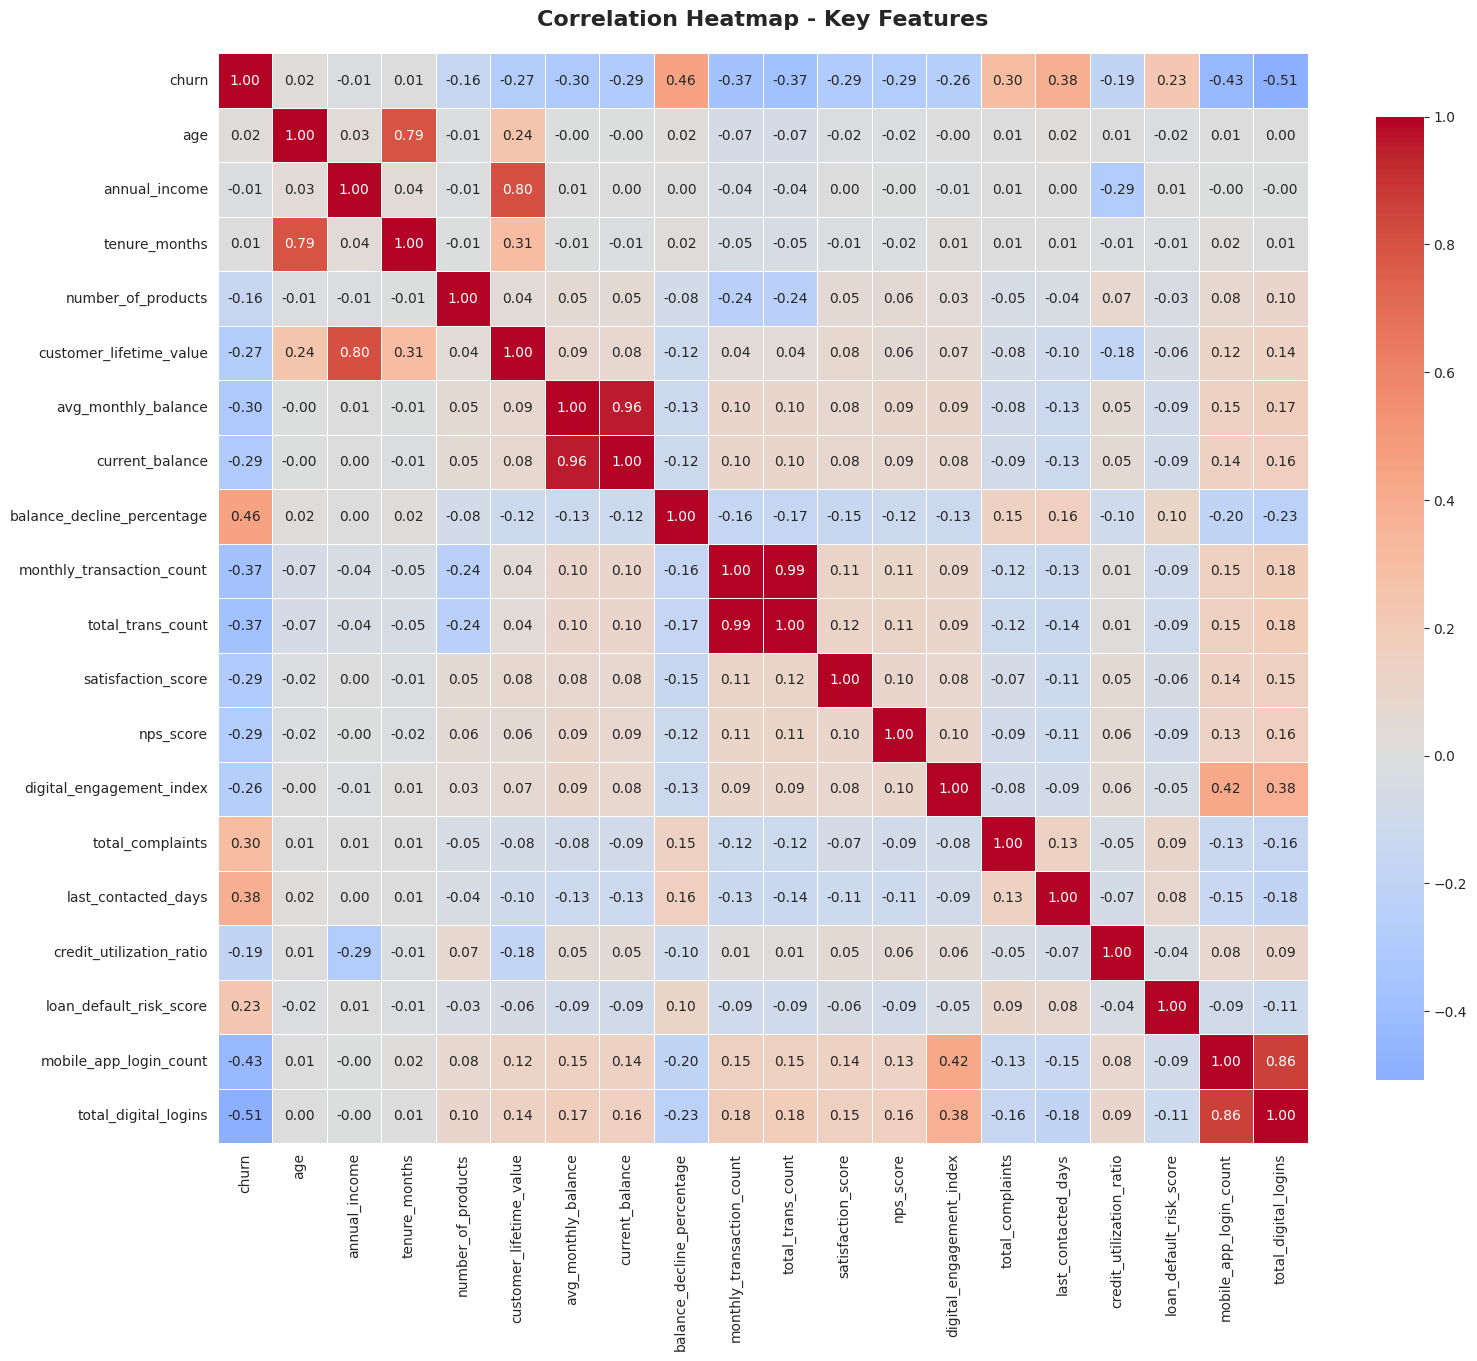


TOP CORRELATIONS WITH CHURN
balance_decline_percentage    0.455938
last_contacted_days           0.383718
total_complaints              0.303294
loan_default_risk_score       0.231309
age                           0.017256
tenure_months                 0.008124
annual_income                -0.009114
number_of_products           -0.157092
credit_utilization_ratio     -0.188519
digital_engagement_index     -0.259963
Name: churn, dtype: float64

--------------------------------------------------------------------------------
digital_engagement_index    -0.259963
customer_lifetime_value     -0.272978
nps_score                   -0.289284
satisfaction_score          -0.291526
current_balance             -0.293860
avg_monthly_balance         -0.301835
monthly_transaction_count   -0.367574
total_trans_count           -0.372500
mobile_app_login_count      -0.427283
total_digital_logins        -0.507769
Name: churn, dtype: float64


In [5]:
# Select numerical features for correlation analysis
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Remove customer_id and select key features for correlation
key_numerical_features = [
    'churn', 'age', 'annual_income', 'tenure_months', 'number_of_products',
    'customer_lifetime_value', 'avg_monthly_balance', 'current_balance',
    'balance_decline_percentage', 'monthly_transaction_count',
    'total_trans_count', 'satisfaction_score', 'nps_score',
    'digital_engagement_index', 'total_complaints', 'last_contacted_days',
    'credit_utilization_ratio', 'loan_default_risk_score',
    'mobile_app_login_count', 'total_digital_logins'
]

# Calculate correlation matrix
corr_matrix = df[key_numerical_features].corr()

# Create heatmap
plt.figure(figsize=(16, 14))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap - Key Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Show top correlations with churn
print("\n" + "=" * 80)
print("TOP CORRELATIONS WITH CHURN")
print("=" * 80)
churn_corr = corr_matrix['churn'].sort_values(ascending=False)
print(churn_corr[1:11])  # Top 10 positive correlations
print("\n" + "-" * 80)
print(churn_corr[-10:])  # Top 10 negative correlations

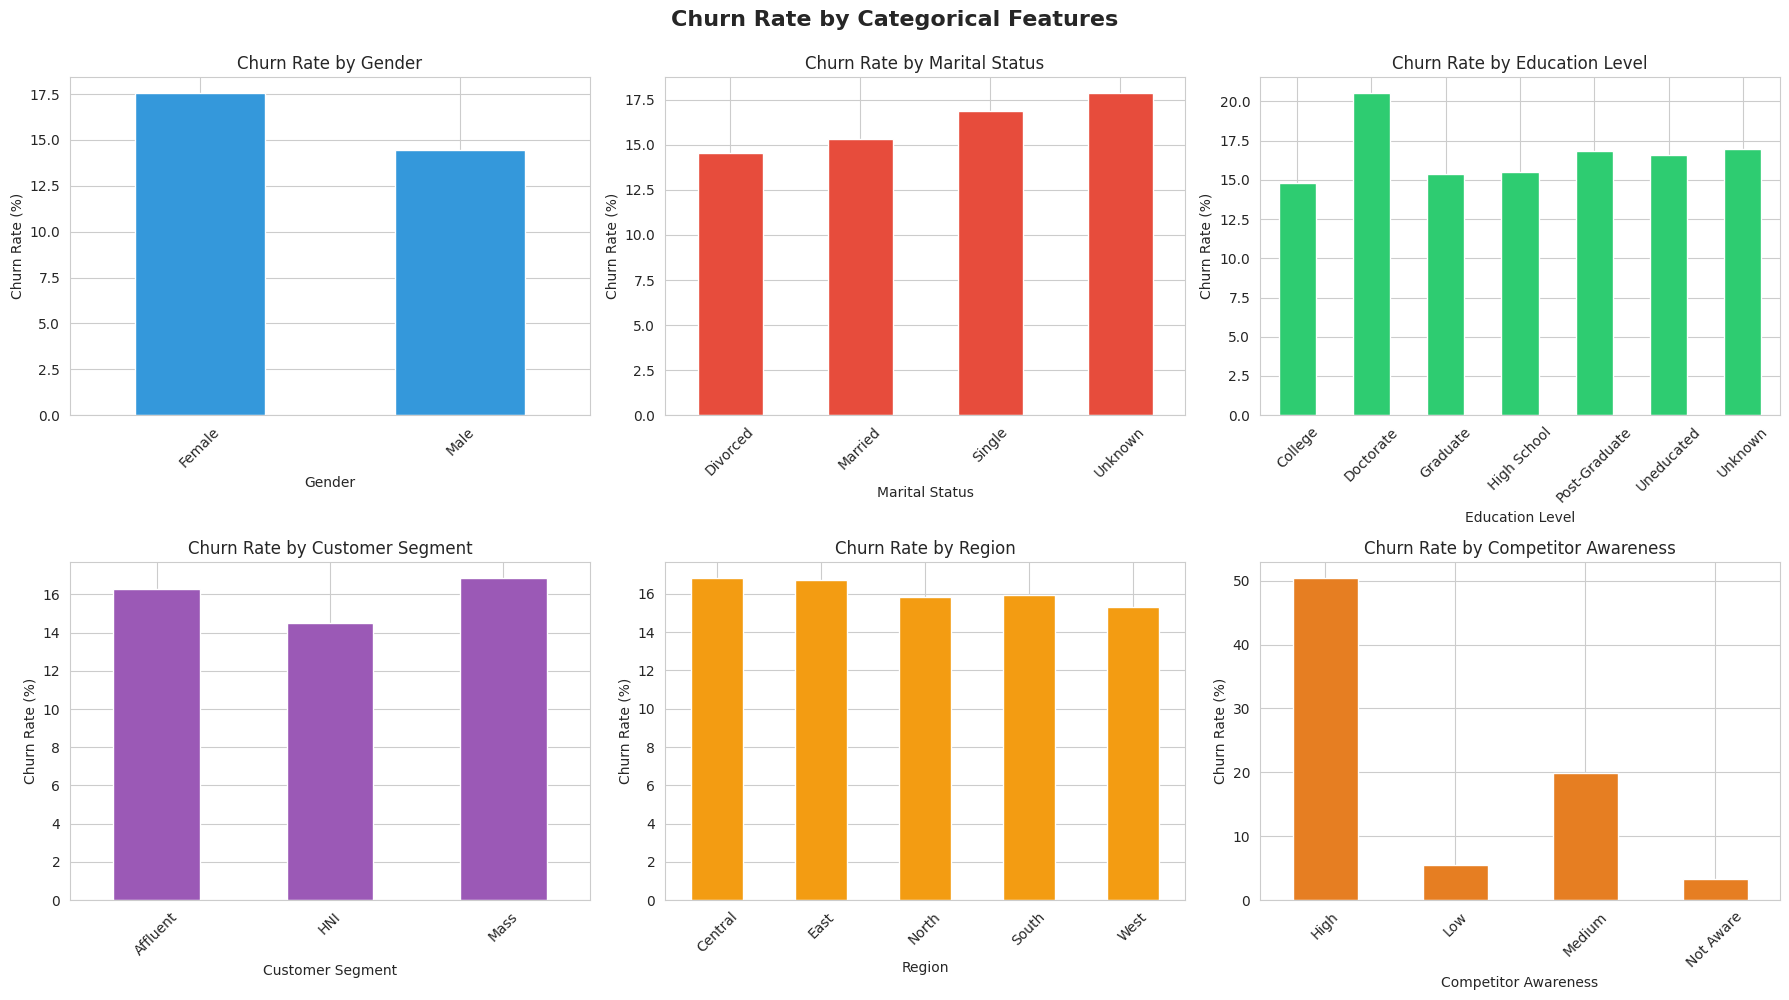

In [6]:
# Categorical features analysis
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Churn Rate by Categorical Features', fontsize=16, fontweight='bold', y=0.995)

# 1. Gender
gender_churn = df.groupby('gender')['churn'].agg(['sum', 'count'])
gender_churn['churn_rate'] = (gender_churn['sum'] / gender_churn['count'] * 100)
gender_churn['churn_rate'].plot(kind='bar', ax=axes[0, 0], color='#3498db')
axes[0, 0].set_title('Churn Rate by Gender')
axes[0, 0].set_ylabel('Churn Rate (%)')
axes[0, 0].set_xlabel('Gender')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Marital Status
marital_churn = df.groupby('marital_status')['churn'].agg(['sum', 'count'])
marital_churn['churn_rate'] = (marital_churn['sum'] / marital_churn['count'] * 100)
marital_churn['churn_rate'].plot(kind='bar', ax=axes[0, 1], color='#e74c3c')
axes[0, 1].set_title('Churn Rate by Marital Status')
axes[0, 1].set_ylabel('Churn Rate (%)')
axes[0, 1].set_xlabel('Marital Status')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Education Level
education_churn = df.groupby('education_level')['churn'].agg(['sum', 'count'])
education_churn['churn_rate'] = (education_churn['sum'] / education_churn['count'] * 100)
education_churn['churn_rate'].plot(kind='bar', ax=axes[0, 2], color='#2ecc71')
axes[0, 2].set_title('Churn Rate by Education Level')
axes[0, 2].set_ylabel('Churn Rate (%)')
axes[0, 2].set_xlabel('Education Level')
axes[0, 2].tick_params(axis='x', rotation=45)

# 4. Customer Segment
segment_churn = df.groupby('customer_segment')['churn'].agg(['sum', 'count'])
segment_churn['churn_rate'] = (segment_churn['sum'] / segment_churn['count'] * 100)
segment_churn['churn_rate'].plot(kind='bar', ax=axes[1, 0], color='#9b59b6')
axes[1, 0].set_title('Churn Rate by Customer Segment')
axes[1, 0].set_ylabel('Churn Rate (%)')
axes[1, 0].set_xlabel('Customer Segment')
axes[1, 0].tick_params(axis='x', rotation=45)

# 5. Region
region_churn = df.groupby('region')['churn'].agg(['sum', 'count'])
region_churn['churn_rate'] = (region_churn['sum'] / region_churn['count'] * 100)
region_churn['churn_rate'].plot(kind='bar', ax=axes[1, 1], color='#f39c12')
axes[1, 1].set_title('Churn Rate by Region')
axes[1, 1].set_ylabel('Churn Rate (%)')
axes[1, 1].set_xlabel('Region')
axes[1, 1].tick_params(axis='x', rotation=45)

# 6. Competitor Bank Offer Awareness
competitor_churn = df.groupby('competitor_bank_offer_awareness')['churn'].agg(['sum', 'count'])
competitor_churn['churn_rate'] = (competitor_churn['sum'] / competitor_churn['count'] * 100)
competitor_churn['churn_rate'].plot(kind='bar', ax=axes[1, 2], color='#e67e22')
axes[1, 2].set_title('Churn Rate by Competitor Awareness')
axes[1, 2].set_ylabel('Churn Rate (%)')
axes[1, 2].set_xlabel('Competitor Awareness')
axes[1, 2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [7]:
print("=" * 80)
print("KEY INSIGHTS FROM DATA EXPLORATION")
print("=" * 80)

# 1. Churn by digital engagement
print("\n1. DIGITAL ENGAGEMENT IMPACT")
print("-" * 80)
df['digital_engagement_category'] = pd.cut(df['digital_engagement_index'],
                                            bins=[0, 40, 50, 60, 100],
                                            labels=['Low', 'Medium', 'High', 'Very High'])
digital_churn = df.groupby('digital_engagement_category')['churn'].agg(['sum', 'count', 'mean'])
digital_churn.columns = ['Churned', 'Total', 'Churn_Rate']
digital_churn['Churn_Rate'] = (digital_churn['Churn_Rate'] * 100).round(2)
print(digital_churn)

# 2. Churn by transaction activity
print("\n2. TRANSACTION ACTIVITY IMPACT")
print("-" * 80)
df['transaction_category'] = pd.cut(df['total_trans_count'],
                                     bins=[0, 40, 60, 80, 150],
                                     labels=['Low', 'Medium', 'High', 'Very High'])
trans_churn = df.groupby('transaction_category')['churn'].agg(['sum', 'count', 'mean'])
trans_churn.columns = ['Churned', 'Total', 'Churn_Rate']
trans_churn['Churn_Rate'] = (trans_churn['Churn_Rate'] * 100).round(2)
print(trans_churn)

# 3. Churn by balance decline
print("\n3. BALANCE DECLINE IMPACT")
print("-" * 80)
df['balance_decline_category'] = pd.cut(df['balance_decline_percentage'],
                                         bins=[-100, 0, 5, 10, 100],
                                         labels=['Negative/No Decline', 'Low (0-5%)', 'Medium (5-10%)', 'High (>10%)'])
balance_churn = df.groupby('balance_decline_category')['churn'].agg(['sum', 'count', 'mean'])
balance_churn.columns = ['Churned', 'Total', 'Churn_Rate']
balance_churn['Churn_Rate'] = (balance_churn['Churn_Rate'] * 100).round(2)
print(balance_churn)

# 4. Churn by satisfaction score
print("\n4. SATISFACTION SCORE IMPACT")
print("-" * 80)
df['satisfaction_category'] = pd.cut(df['satisfaction_score'],
                                      bins=[0, 2, 3, 4, 5],
                                      labels=['Low (1-2)', 'Medium (2-3)', 'High (3-4)', 'Very High (4-5)'])
satisfaction_churn = df.groupby('satisfaction_category')['churn'].agg(['sum', 'count', 'mean'])
satisfaction_churn.columns = ['Churned', 'Total', 'Churn_Rate']
satisfaction_churn['Churn_Rate'] = (satisfaction_churn['Churn_Rate'] * 100).round(2)
print(satisfaction_churn)

# 5. Product holdings impact
print("\n5. PRODUCT HOLDINGS IMPACT")
print("-" * 80)
product_churn = df.groupby('number_of_products')['churn'].agg(['sum', 'count', 'mean'])
product_churn.columns = ['Churned', 'Total', 'Churn_Rate']
product_churn['Churn_Rate'] = (product_churn['Churn_Rate'] * 100).round(2)
print(product_churn)

KEY INSIGHTS FROM DATA EXPLORATION

1. DIGITAL ENGAGEMENT IMPACT
--------------------------------------------------------------------------------
                             Churned  Total  Churn_Rate
digital_engagement_category                            
Low                              362   1002       36.13
Medium                           455   2090       21.77
High                             407   3562       11.43
Very High                         78   1447        5.39

2. TRANSACTION ACTIVITY IMPACT
--------------------------------------------------------------------------------
                      Churned  Total  Churn_Rate
transaction_category                            
Low                       492   1572       31.30
Medium                    624   1694       36.84
High                      160   2785        5.75
Very High                  26   2050        1.27

3. BALANCE DECLINE IMPACT
--------------------------------------------------------------------------------
   

/tmp/ipykernel_3487/4054381773.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  digital_churn = df.groupby('digital_engagement_category')['churn'].agg(['sum', 'count', 'mean'])
/tmp/ipykernel_3487/4054381773.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trans_churn = df.groupby('transaction_category')['churn'].agg(['sum', 'count', 'mean'])
/tmp/ipykernel_3487/4054381773.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence thi

## 3. Data Preprocessing and Feature Engineering

Based on our exploration, we'll now preprocess the data. This involves:
1.  **Handling Missing Values:** Addressing the `app_rating_given` column.
2.  **Feature Engineering:** Creating new features to capture more predictive power.
3.  **Encoding Categorical Variables:** Converting categorical columns into a numerical format.
4.  **Scaling Numerical Features:** Standardizing numerical features.

In [8]:
# Make a copy of the original dataframe to preserve it
df_processed = df.copy()

### Handling Missing Values

Given that 'app_rating_given' has over 50% missing values, dropping this column is a reasonable approach to avoid introducing bias or noise through imputation.

In [9]:
# Drop 'app_rating_given' due to high percentage of missing values
df_processed = df_processed.drop(columns=['app_rating_given'])
print(f"'app_rating_given' column dropped. Remaining shape: {df_processed.shape}")

'app_rating_given' column dropped. Remaining shape: (8101, 101)


### Feature Engineering

We will create some new features that might capture more nuanced information relevant to churn.

In [10]:
# 1. Financial Health Score (hypothetical, combining balance and income)
df_processed['financial_health_score'] = (
    df_processed['annual_income'] +
    df_processed['current_balance'] -
    (df_processed['debt_to_income_ratio'] * df_processed['annual_income']) # Subtract estimated debt
)

# 2. Digital Activity Ratio (mobile app logins as a proportion of total digital logins)
df_processed['digital_activity_ratio'] = (
    df_processed['mobile_app_login_count']
) / (df_processed['total_digital_logins'] + 1e-6) # Add small epsilon to avoid division by zero

# 3. Product Diversification Score (how many products relative to max possible?)
df_processed['product_diversification_score'] = df_processed['number_of_products'] / df_processed['number_of_products'].max()

# 4. Monthly Engagement Score (combining transactions and total digital logins)
df_processed['monthly_engagement_score'] = (
    df_processed['monthly_transaction_count'] +
    df_processed['total_digital_logins']
)

print("New features engineered successfully.")

# Display summary statistics for new features
print("\nSummary Statistics for New Features:")
new_features_summary = df_processed[['financial_health_score', 'digital_activity_ratio',
                                     'product_diversification_score', 'monthly_engagement_score']].describe().T
print(new_features_summary.round(2))

New features engineered successfully.

Summary Statistics for New Features:
                                count      mean       std        min      25%  \
financial_health_score         8101.0  56153.41  45197.11 -301539.00  31285.0   
digital_activity_ratio         8101.0      0.66      0.10       0.23      0.6   
product_diversification_score  8101.0      0.64      0.26       0.17      0.5   
monthly_engagement_score       8101.0     32.99      7.03      10.00     28.0   

                                    50%       75%       max  
financial_health_score         52736.53  80028.98  257933.9  
digital_activity_ratio             0.67      0.72       1.0  
product_diversification_score      0.67      0.83       1.0  
monthly_engagement_score          33.00     38.00      56.0  


### Encoding Categorical Variables

We will use one-hot encoding for nominal categorical features and label encoding for ordinal features if any are present. First, identify categorical columns.

In [11]:
# Identify categorical columns (excluding 'customer_id' and 'churn')
categorical_cols = df_processed.select_dtypes(include='object').columns.tolist()

print(f"Categorical columns identified: {categorical_cols}")

# Apply one-hot encoding
df_processed = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)

print(f"\nShape after one-hot encoding: {df_processed.shape}")

Categorical columns identified: ['gender', 'marital_status', 'education_level', 'occupation_type', 'income_band', 'income_category', 'city_tier', 'region', 'customer_segment', 'onboarding_channel', 'relationship_type', 'primary_account_type', 'card_category', 'competitor_bank_offer_awareness', 'customer_feedback_sentiment']

Shape after one-hot encoding: (8101, 141)


### Scaling Numerical Features

Scaling numerical features is crucial for many machine learning algorithms. We will use `StandardScaler` to standardize the features (mean=0, variance=1).

In [12]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns to scale (exclude 'customer_id' and 'churn')
numerical_cols_to_scale = df_processed.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols_to_scale.remove('customer_id')
numerical_cols_to_scale.remove('churn')

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling
df_processed[numerical_cols_to_scale] = scaler.fit_transform(df_processed[numerical_cols_to_scale])

print("Numerical features scaled successfully.")

# Display the first few rows of the processed DataFrame
print("\nFirst 5 rows of the processed DataFrame:")
display(df_processed.head())

Numerical features scaled successfully.

First 5 rows of the processed DataFrame:


,customer_id,churn,age,dependent_count,annual_income,tenure_months,number_of_products,customer_lifetime_value,loyalty_program_member,referral_count,...,primary_account_type_Salary,primary_account_type_Savings,card_category_Gold,card_category_Platinum,card_category_Silver,competitor_bank_offer_awareness_Low,competitor_bank_offer_awareness_Medium,competitor_bank_offer_awareness_Not Aware,customer_feedback_sentiment_Neutral,customer_feedback_sentiment_Positive
0,133001,0,-1.301232,-1.809900,-1.067097,-1.513205,0.122196,-0.877297,-1.089539,-0.972291,...,False,True,False,False,False,False,False,True,False,True
1,133002,1,-0.299340,0.501503,0.181481,-0.000700,0.765411,-0.879448,0.917819,-0.972291,...,True,False,False,False,True,False,False,False,False,True
2,133003,0,-0.048867,-0.268965,1.098301,-0.756952,1.408625,0.862652,-1.089539,-0.972291,...,False,True,False,False,False,True,False,False,False,True
3,133004,0,-1.301232,-0.268965,-0.940644,-1.513205,-0.521019,-1.075833,0.917819,0.885820,...,False,True,False,False,False,False,True,False,True,False
4,133005,0,0.452079,-1.039432,2.973836,0.503468,0.122196,3.091749,-1.089539,0.885820,...,False,True,False,False,False,True,False,False,False,True
